In [1]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum
import util_charge as yuc

enss=['b','c','d','e']

# 2pt

In [2]:
ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2Njk[ens]=len(c2pt)

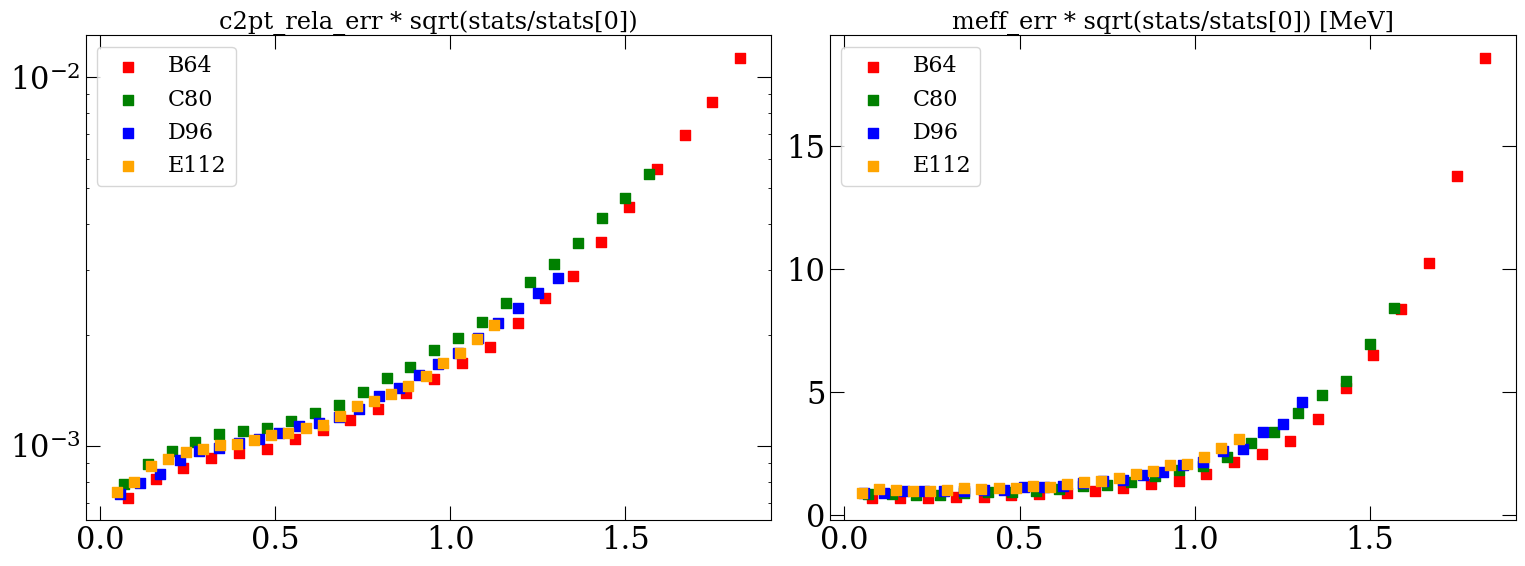

In [3]:
Nsrcs=np.array([200+85+64,650,256+112,100+127+84])
Ncfgs=np.array([ens2Njk[ens] for ens in enss])
stats=Nsrcs*Ncfgs
# rescales=np.sqrt(stats)
rescales=np.sqrt(stats/stats[0])

fig, axs = yu.getFigAxs(1,2)
yu.addColHeader(axs,['c2pt_rela_err * sqrt(stats/stats[0])','meff_err * sqrt(stats/stats[0]) [MeV]'])
ax=axs[0,0]
colors=['r','g','b','orange']
for i_ens,ens in enumerate(enss):
    xunit=yu.ens2a[ens]
    t=ens2c2pt0[ens]
    
    color=colors[i_ens]
    for i_tf,tf in enumerate(range(1,24)):
        mean,err=yu.jackme(t[:,tf])
        plt_y=err*rescales[i_ens]/mean
        ax.scatter(tf*xunit,plt_y, color=color, marker='s', label=yu.ens2label[ens] if i_tf==0 else None)
    ax.set_yscale('log')
ax.legend()

ax=axs[0,1]
colors=['r','g','b','orange']
for i_ens,ens in enumerate(enss):
    xunit=yu.ens2a[ens]
    t=ens2c2pt0[ens]
    t=yu.jackmap(yu.c2pt2meff,t)
    
    color=colors[i_ens]
    for i_tf,tf in enumerate(range(1,24)):
        mean,err=yu.jackme(t[:,tf])
        plt_y=err*rescales[i_ens]
        ax.scatter(tf*xunit,plt_y*yu.ens2aInv[ens], color=color, marker='s', label=yu.ens2label[ens] if i_tf==0 else None)
ax.legend()

yu.finalizePlot()

# local

In [4]:
symmetrizeQ=True
extraLabel='' if symmetrizeQ else '_0sym'

[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl_reg('ens2pars_jk_meffnst_selected',pathlabel='analysis_c2pt')

enss=['b','c','d','e']
ens2data={}
for ens in enss:
    path=f'/p/project1/ngff/li47/code/projectData/07_Nsgm/charges/{yu.ens2full[ens]}.h5'
    [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=yuc.load(path,symmetrizeQ=symmetrizeQ)
    ens2data[ens]=[c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]

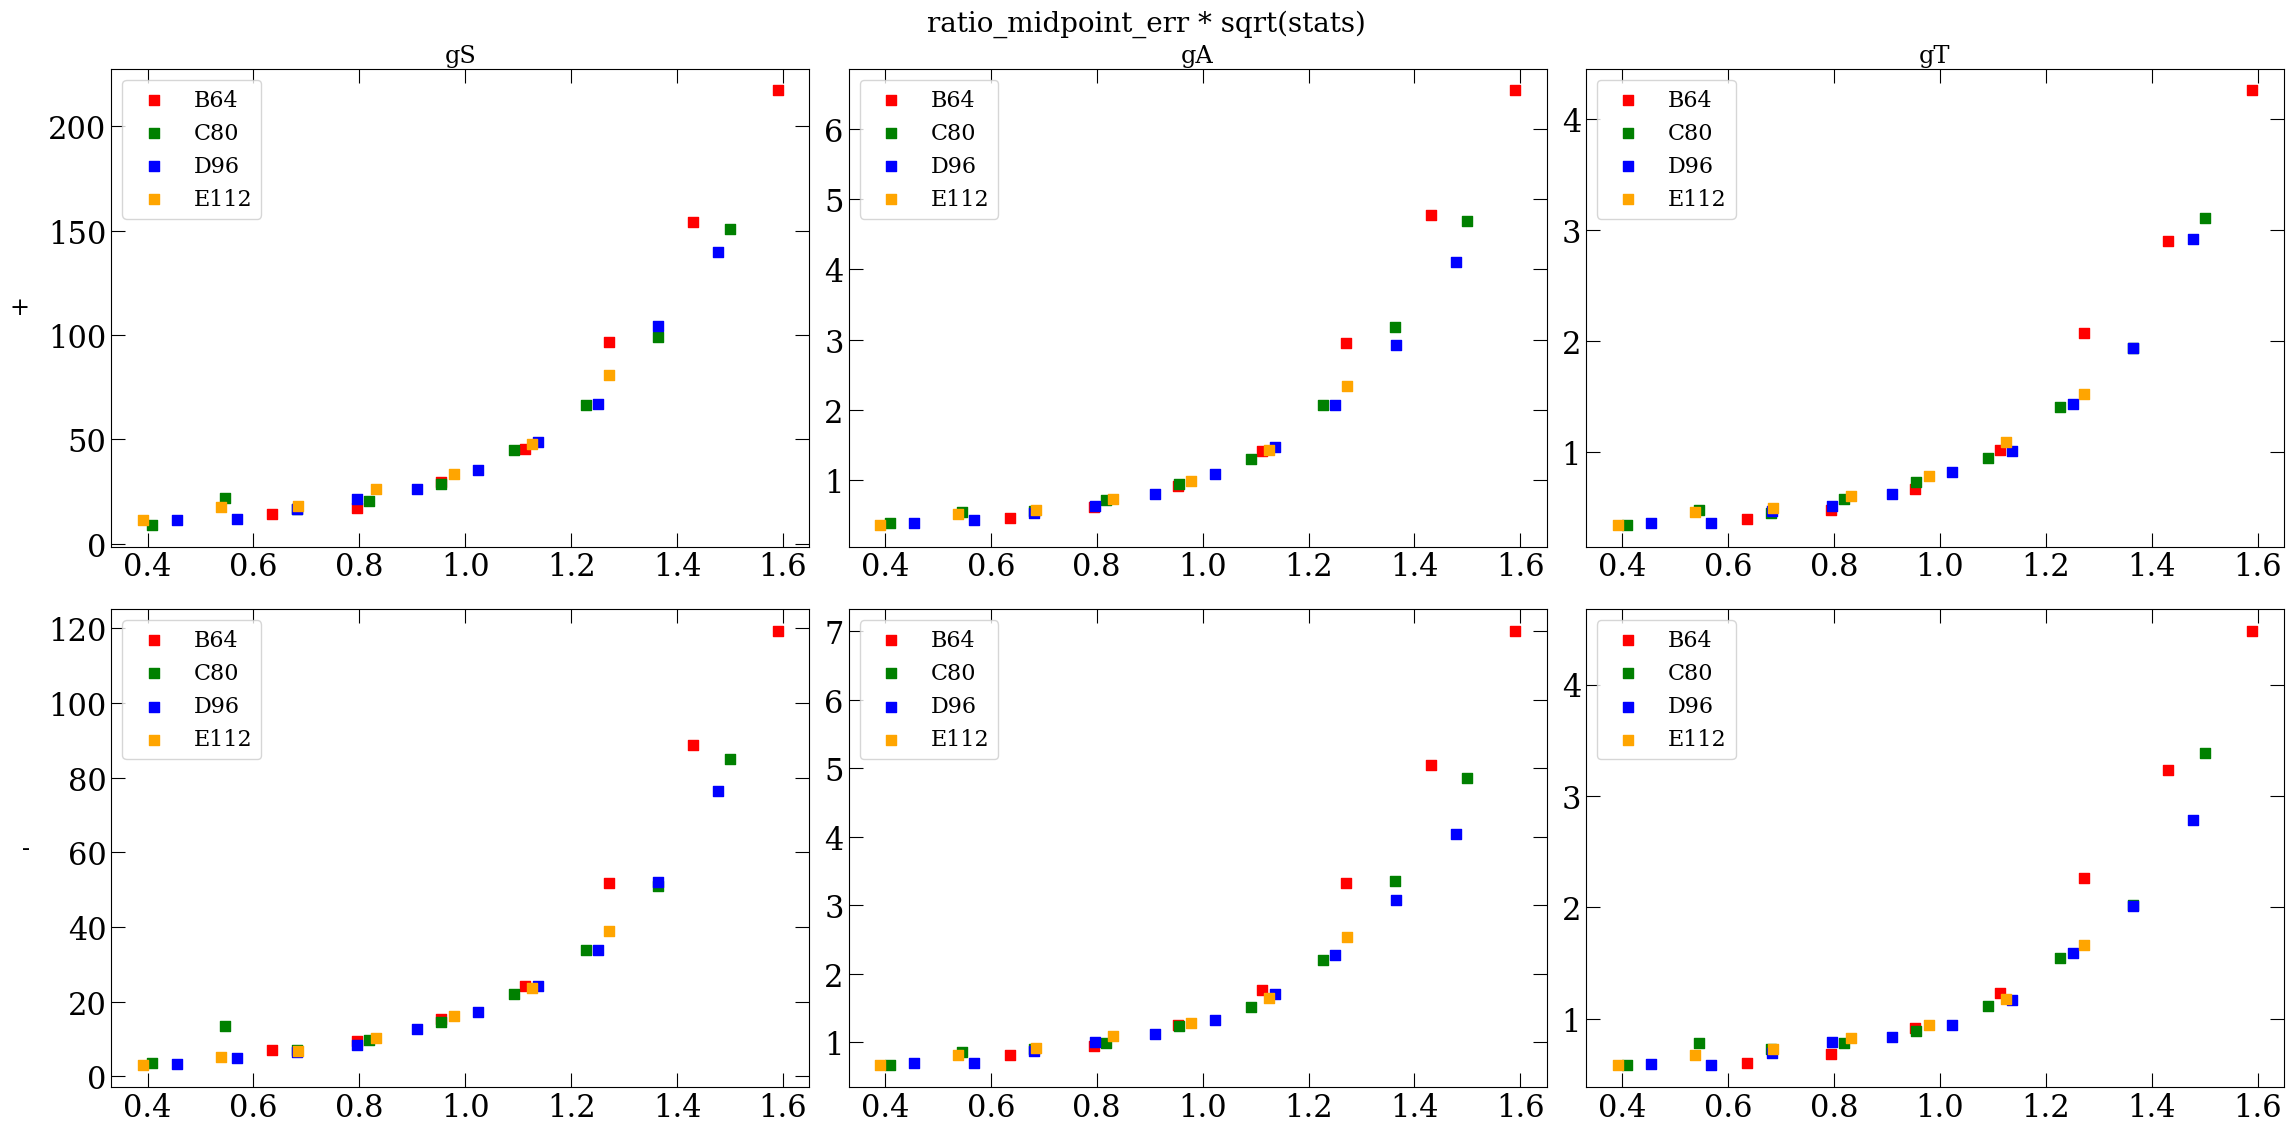

In [5]:
ens2tf2Nsrcs={
    'b':{8:1, 10:2, 12:4+1, 14:6+4, 16:16+16, 18:48+64, 20:64+64},
    'c':{6:1, 8:2, 10:4, 12:10, 14:22, 16:48, 18:45, 20:116, 22:246},
    'd':{8:1, 10:2, 12:4, 14:8, 16:16, 18:32, 20:64, 22:16, 24:32, 26:64},
    'e':{8:1, 11:2, 14:4, 17:8, 20:16, 23:32, 26:64},
}

gs=['gS','gA','gT']
flas=['+','-']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle('ratio_midpoint_err * sqrt(stats)')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ifla,ig]
        for iens,ens in enumerate(enss):
            [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
            xunit=yu.ens2a[ens]
            tfs=list(ens2tf2Nsrcs[ens].keys()); tfs.sort()
            for itf,tf in enumerate(tfs):
                c3pt=key2tf2c3pt[f'{g}{fla};conn'][tf][:,tf//2]
                c2pt=c2pt_disc[:,tf]
                t=c3pt/c2pt
                
                Ncfg=len(t); Nsrc=ens2tf2Nsrcs[ens][tf]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale
                ax.scatter(tf*xunit,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()

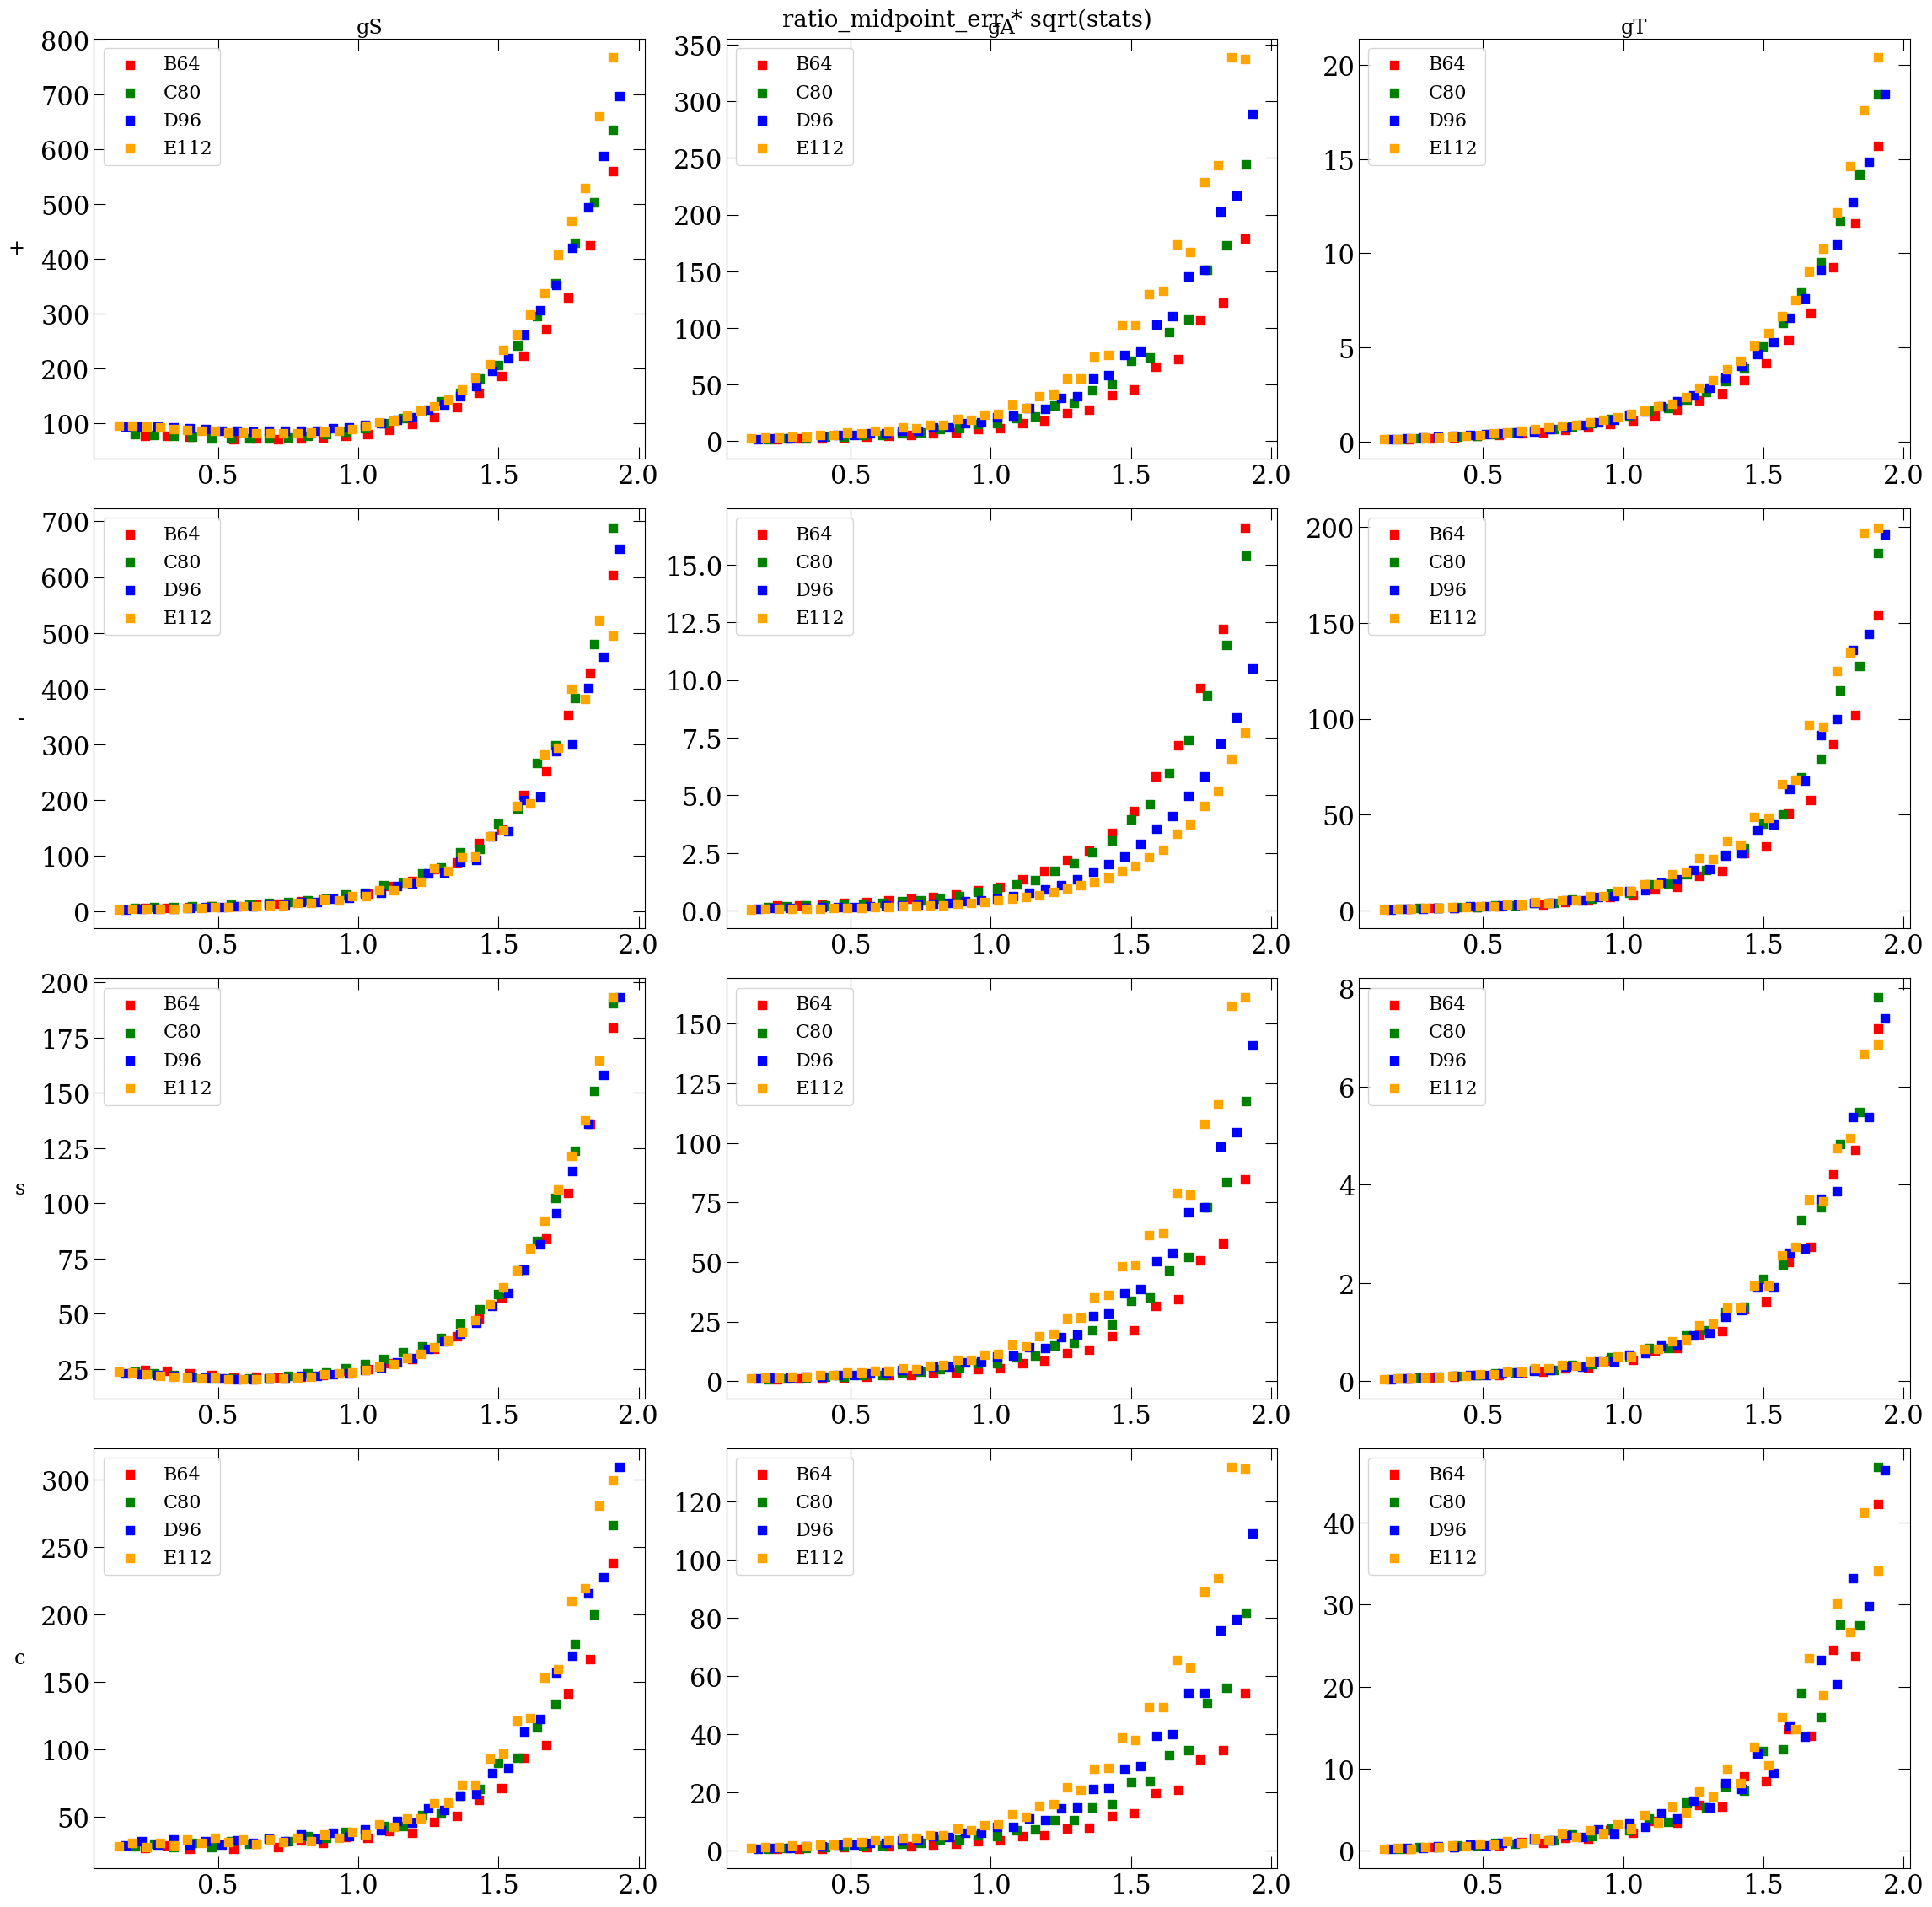

In [ ]:
ens2Nsrcs={
    'b':200+85+64,
    'c':650,
    'd':256+112,
    'e':100+127+84+16+12,
}

gs=['gS','gA','gT']
flas=['+','-','s','c']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle('ratio_midpoint_err * sqrt(stats)')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ig,ig]
        for iens,ens in enumerate(enss):
            [c2pt_disc,tfs_conn,tfs_disc,tf2c2pt_conn,key2tf2c3pt,key2tf2ratio]=ens2data[ens]
            xunit=yu.ens2a[ens]
            for itf,tf in enumerate(range(3,int(2/xunit))):
                c3pt=key2tf2c3pt[f'{g}{fla};disc'][tf][:,tf//2]
                c2pt=c2pt_disc[:,tf]
                t=c3pt/c2pt
                
                Ncfg=len(t); Nsrc=ens2Nsrcs[ens]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale
                ax.scatter(tf*xunit,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()

# 1DV

In [43]:
key2tf2ratio={}
projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']
for ens in enss:
    key2tf2ratio[(ens,'j+;conn')]={}
    key2tf2ratio[(ens,'j-;conn')]={}
    
    app='_cfgs_conn_Giannis_fine' if ens=='e' else ''
    
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    
    mN_jk=ens2pars_jk_meff2st[ens][:,0]
    if ens=='e':
        mN_jk=yu.load_pkl_reg('ens2pars_jk_meffnst_selected',pathlabel='analysis_conn_Eensemble_withLessCfg')[1][ens][:,0]
    
    factor_equal=1/(-3*mN_jk/4)
    
    path=f'{basepath}/conn_2pt{app}.h5'
    with h5py.File(path) as f:
        moms=yu.moms2list(f['moms'])
        imom=moms.index([0,0,0])
        
        tf2c2pt={}
        for tf in f['data'].keys():
            t=f[f'data/{tf}'][:]
            t=yu.jackknife(np.real(t[:,:,imom]))
            tf2c2pt[int(tf)]=t

    path=f'{basepath}/conn_0,0,0,0,0,0{app}.h5'
    with h5py.File(path) as f:
        moms=yu.moms2list(f['moms'])
        imom=moms.index([0,0,0,0,0,0])
        
        for jtf in f['data'].keys():
            j,tf=jtf.split('_'); tf=int(tf)
            t=f[f'data/{jtf}'][:]
            t=t[:,:,0,projs.index('P0'),inserts.index('tt')]
            c3pt=yu.jackknife(t)
            ratio=np.real(c3pt/tf2c2pt[tf][:,tf:tf+1]*factor_equal[:,None])
            key=(ens,j)
            key2tf2ratio[key][tf]=ratio
            
ens2tfs_conn={}
for ens in enss:
    tfs=list(key2tf2ratio[(ens,'j+;conn')].keys()); tfs.sort()
    ens2tfs_conn[ens]=tfs
    print(ens,tfs)

b [8, 10, 12, 14, 16, 18, 20]
c [6, 8, 10, 12, 14, 16, 18, 20, 22]
d [8, 10, 12, 14, 16, 18, 20, 22, 24, 26]
e [8, 11, 14, 17, 20, 23, 26]


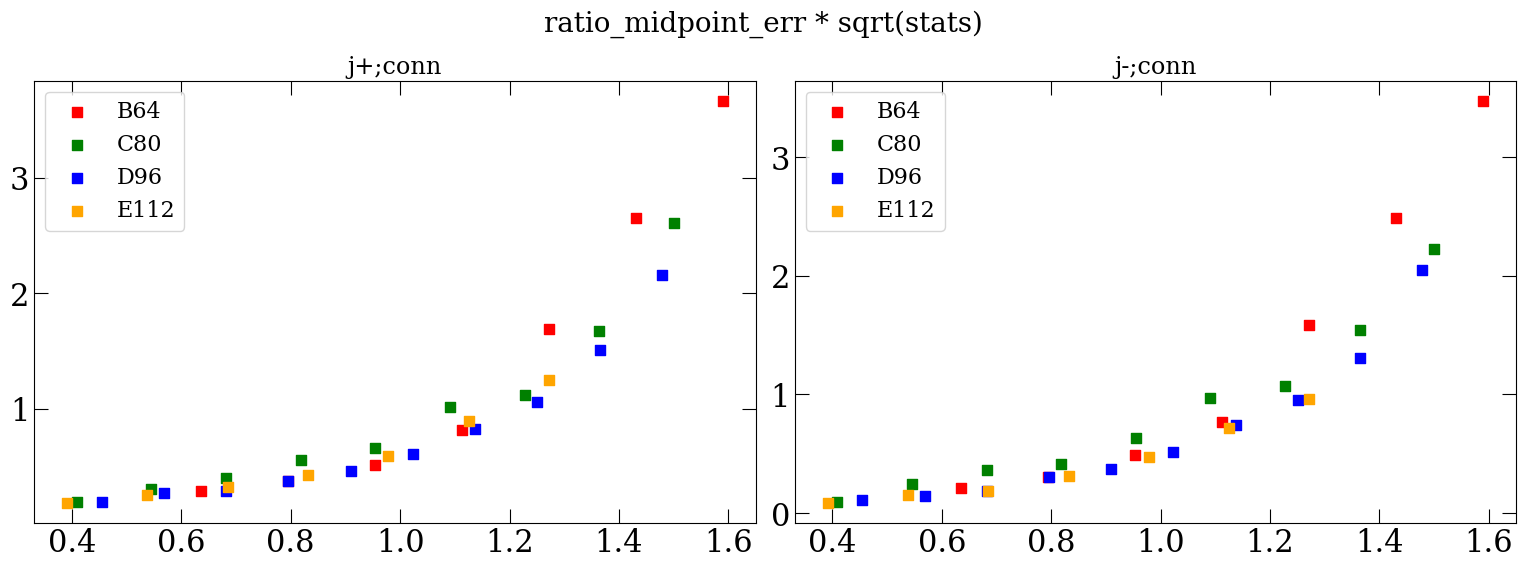

In [44]:
ens2tf2Nsrcs={
    'b':{8:1, 10:2, 12:4+1, 14:6+4, 16:16+16, 18:48+64, 20:64+64},
    'c':{6:1, 8:2, 10:4, 12:10, 14:22, 16:48, 18:45, 20:116, 22:246},
    'd':{8:1, 10:2, 12:4, 14:8, 16:16, 18:32, 20:64, 22:16, 24:32, 26:64},
    'e':{8:1, 11:2, 14:4, 17:8, 20:16, 23:32, 26:64},
}

gs=['j+;conn','j-;conn']
flas=['']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle('ratio_midpoint_err * sqrt(stats)')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ifla,ig]
        for iens,ens in enumerate(enss):
            xunit=yu.ens2a[ens]
            tfs=list(ens2tf2Nsrcs[ens].keys()); tfs.sort()
            for itf,tf in enumerate(tfs):
                t=key2tf2ratio[(ens,g)][tf][:,tf//2]
                
                Ncfg=len(t); Nsrc=ens2tf2Nsrcs[ens][tf]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale
                ax.scatter(tf*xunit,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()

In [ ]:
ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2Njk[ens]=len(c2pt)

projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']

key2tf2ratio={}
stouts=[10]
# stouts=range(0,41)
js=['j+;disc','js;disc','jc;disc']+[f'jg;stout{stout}' for stout in stouts]
for ens in enss:
    path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/{yu.ens2full[ens]}/data_merge/disc_0,0,1,0,0,0.h5'
    with h5py.File(path) as f:
        for jtf in f['data'].keys():
            j,tf=jtf.split('_'); tf=int(tf)
            if j not in js:
                continue        
            key=(ens,j)
            if key not in key2tf2ratio:
                key2tf2ratio[key]={}
            c3pt=yu.jackknife(f['data'][jtf][:,:,0,projs.index('P0'),inserts.index('tz')])
            c2pt=ens2c2pt[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
            factor=1/(1j*2*np.pi/yu.ens2NL[ens])
            ratio=np.real(c3pt/c2pt[:,None]*factor)
            key2tf2ratio[key][tf]=ratio
            
ens2tfs_disc={}
for ens in enss:
    tfs=list(key2tf2ratio[(ens,'j+;disc')].keys()); tfs.sort()
    ens2tfs_disc[ens]=tfs
    print(ens,tfs[0],tfs[-1])
    
path='pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)

b 2 22
c 2 26
d 2 30
e 2 32


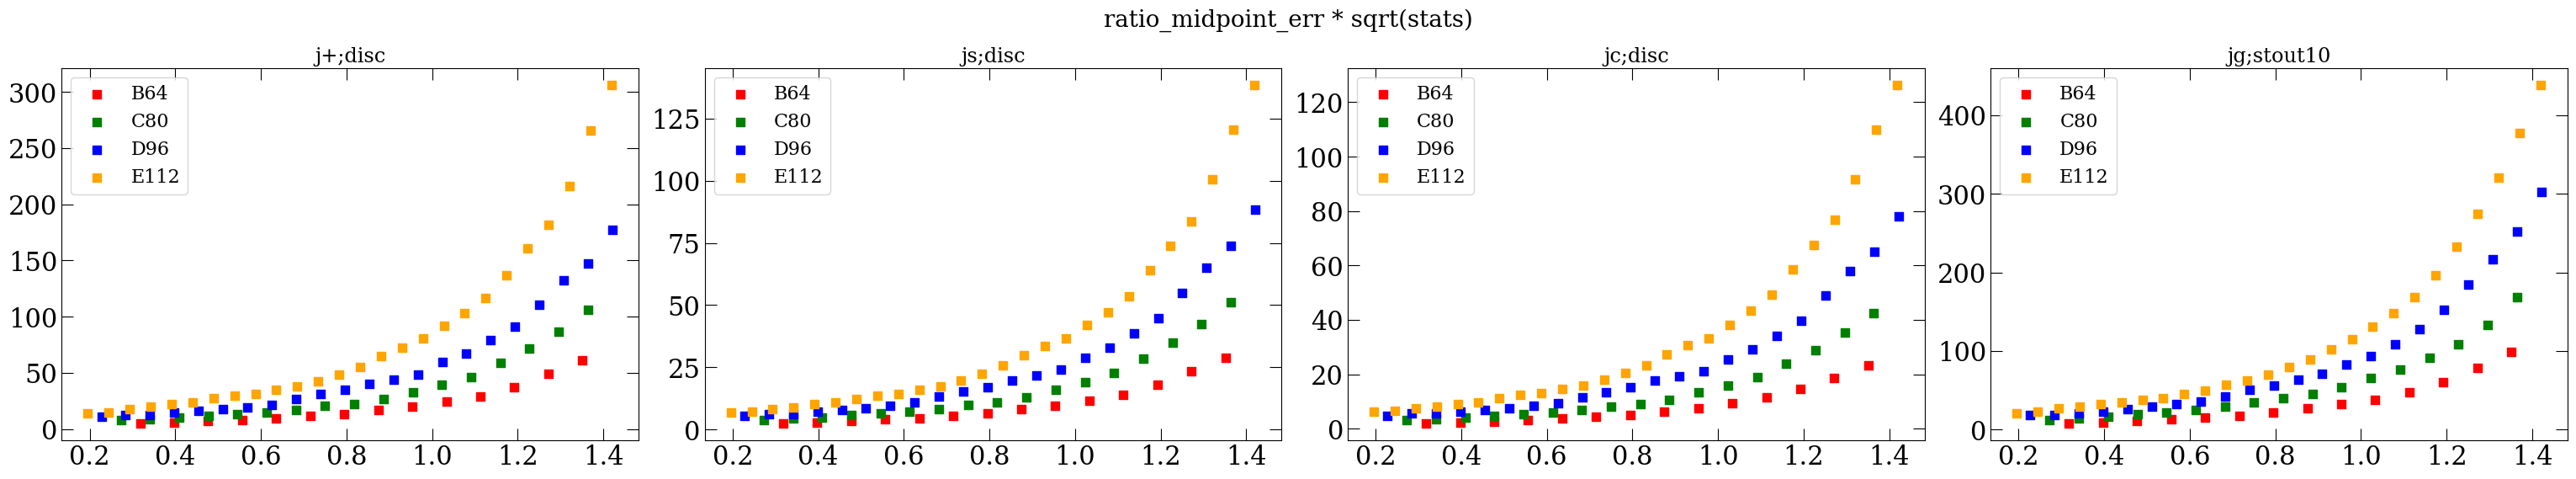

In [46]:
ens2Nsrcs={
    'b':200+85+64,
    'c':650,
    'd':256+112,
    'e':100+127+84,
}

gs=['j+;disc','js;disc','jc;disc','jg;stout10']
flas=['']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle('ratio_midpoint_err * sqrt(stats)')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ifla,ig]
        for iens,ens in enumerate(enss):
            xunit=yu.ens2a[ens]
            for itf,tf in enumerate(range(4,int(1.5/xunit))):
                t=key2tf2ratio[(ens,g)][tf][:,tf//2]
                
                Ncfg=len(t); Nsrc=ens2Nsrcs[ens]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale
                ax.scatter(tf*xunit,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()

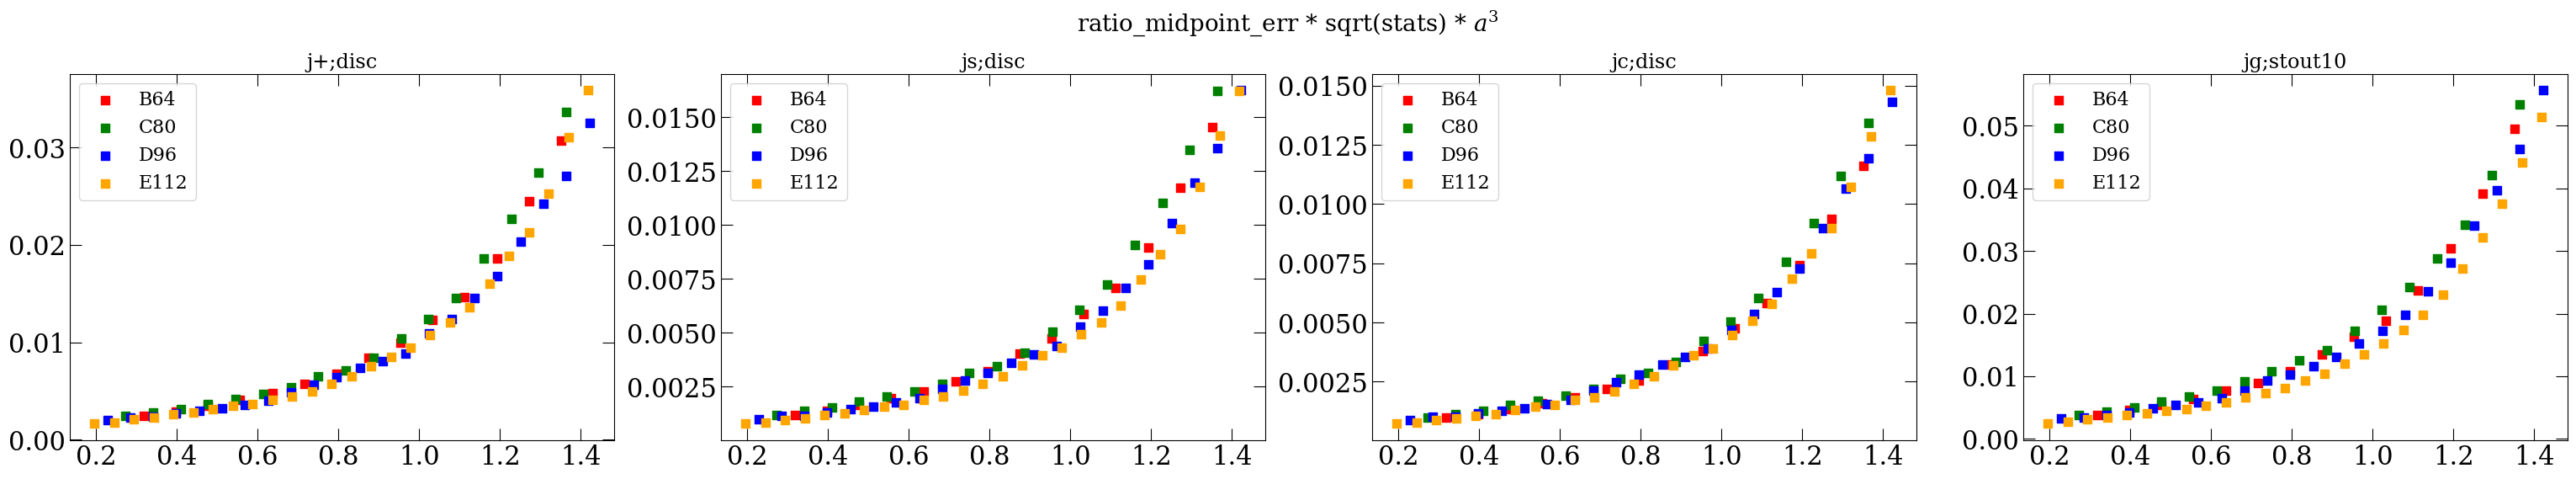

In [55]:
ens2Nsrcs={
    'b':200+85+64,
    'c':650,
    'd':256+112,
    'e':100+127+84,
}

gs=['j+;disc','js;disc','jc;disc','jg;stout10']
flas=['']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle(r'ratio_midpoint_err * sqrt(stats) * $a^3$')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ifla,ig]
        for iens,ens in enumerate(enss):
            xunit=yu.ens2a[ens]
            for itf,tf in enumerate(range(4,int(1.5/xunit))):
                t=key2tf2ratio[(ens,g)][tf][:,tf//2]
                
                Ncfg=len(t); Nsrc=ens2Nsrcs[ens]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale*(yu.ens2a[ens]**3)
                ax.scatter(tf*xunit,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()

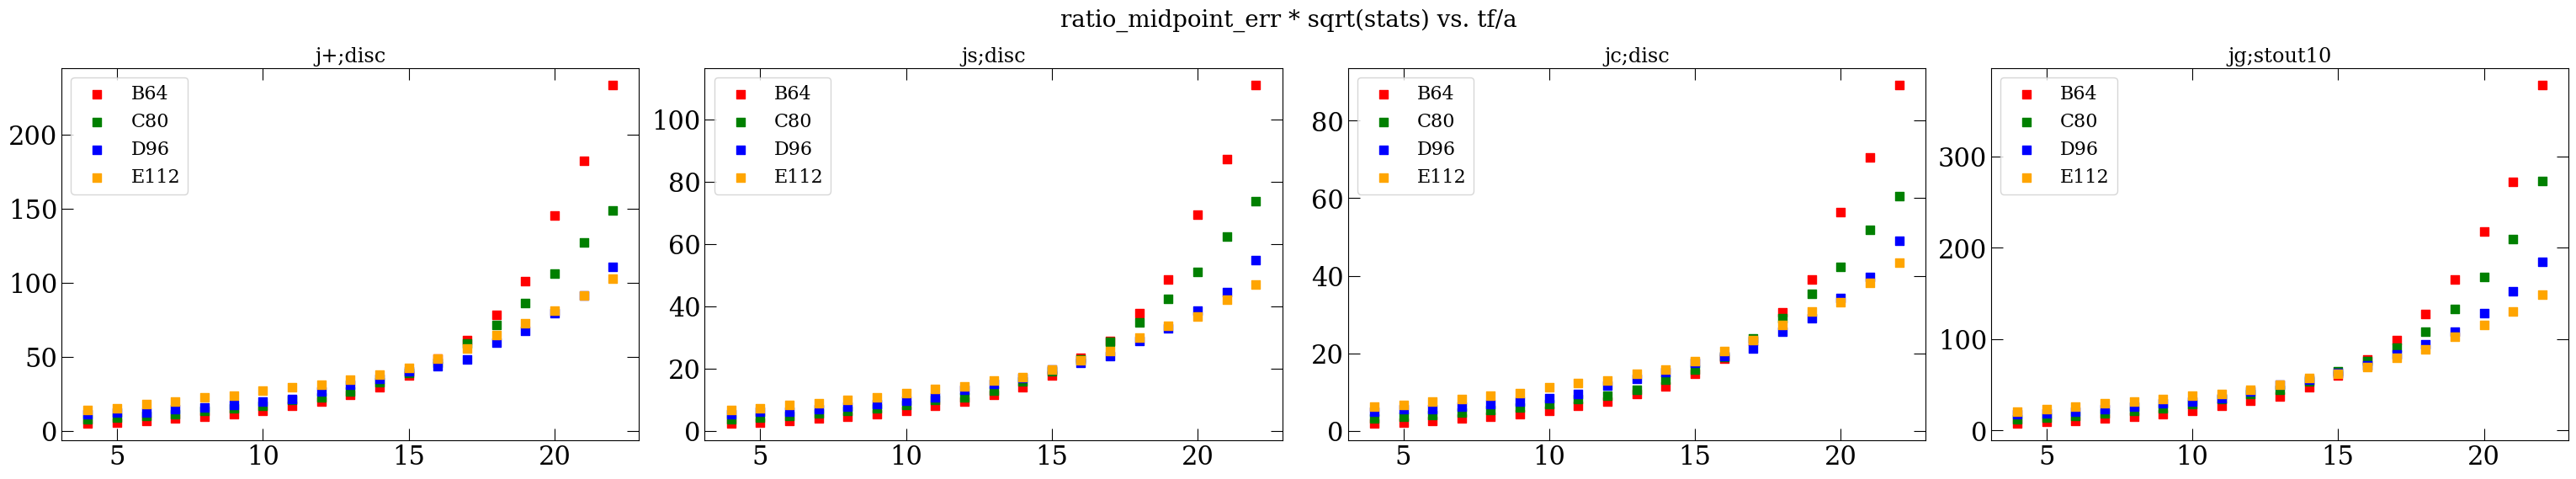

In [71]:
ens2Nsrcs={
    'b':200+85+64,
    'c':650,
    'd':256+112,
    'e':100+127+84,
}

gs=['j+;disc','js;disc','jc;disc','jg;stout10']
flas=['']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle('ratio_midpoint_err * sqrt(stats) vs. tf/a')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ifla,ig]
        for iens,ens in enumerate(enss):
            xunit=yu.ens2a[ens]
            for itf,tf in enumerate(range(4,23)):
                t=key2tf2ratio[(ens,g)][tf][:,tf//2]
                
                Ncfg=len(t); Nsrc=ens2Nsrcs[ens]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale
                ax.scatter(tf,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()

In [7]:
# gluon stout
enss=['b','c','d']
projs=['P0', 'Px', 'Py', 'Pz']
inserts=['tt', 'tx', 'ty', 'tz', 'xx', 'xy', 'xz', 'yy', 'yz', 'zz']

ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2Njk[ens]=len(c2pt)

key2tf2ratio={}
# stouts=[10]
stouts=range(0,41)
js=[f'jg;stout{stout}' for stout in stouts]
for ens in enss:
    path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DV/{yu.ens2full[ens]}/data_merge/disc_0,0,1,0,0,0.h5'
    with h5py.File(path) as f:
        for jtf in f['data'].keys():
            j,tf=jtf.split('_'); tf=int(tf)
            if j not in js:
                continue        
            key=(ens,j)
            if key not in key2tf2ratio:
                key2tf2ratio[key]={}
            c3pt=yu.jackknife(f['data'][jtf][:,:,0,projs.index('P0'),inserts.index('tz')])
            c2pt=ens2c2pt[ens][:,tf,ens2moms_2pt[ens].index([0,0,1])]
            factor=1/(1j*2*np.pi/yu.ens2NL[ens])
            ratio=np.real(c3pt/c2pt[:,None]*factor)
            key2tf2ratio[key][tf]=ratio
            
ens2tfs_disc={}
for ens in enss:
    tfs=list(key2tf2ratio[(ens,'jg;stout10')].keys()); tfs.sort()
    ens2tfs_disc[ens]=tfs
    print(ens,tfs[0],tfs[-1])
    
path='pkl/analysis_c2pt/reg_ignore/ens2pars_jk_meffnst_selected.pkl'
[ens2pars_jk_meff1st,ens2pars_jk_meff2st,ens2pars_jk_meff3st]=yu.load_pkl(path)

b 2 22
c 2 26
d 2 30


In [20]:
nsts=[5,10,20,30,40]
print([np.sqrt(8*rho_stout*nst) for nst in nsts])
for ens in enss:
    rho_stout=0.129
    print(ens,[yu.ens2a[ens]*np.sqrt(8*rho_stout*nst) for nst in nsts])
    
def get(lbd):
    nsts=[round((lbd/(yu.ens2a[ens]*np.sqrt(8*rho_stout)))**2) for ens in enss]
    lbds=[yu.ens2a[ens]*np.sqrt(8*rho_stout*nst) for ens,nst in zip(enss,nsts)]
    print(lbds)
    return nsts
    
get(0.25)

[2.2715633383201093, 3.212475680841802, 4.5431266766402185, 5.5641710972974225, 6.424951361683604]
b [0.18054385412968227, 0.2553275671133064, 0.36108770825936454, 0.44224031881319914, 0.5106551342266128]
c [0.15489790404004825, 0.21905871667660248, 0.3097958080800965, 0.37942082712471126, 0.43811743335320497]
d [0.1291383757834982, 0.18262924245585643, 0.2582767515669964, 0.31632312688135844, 0.36525848491171287]
[0.2553275671133064, 0.24976536540841685, 0.25173703815688303]


[10, 13, 19]

# 1DA

In [60]:
ens2c2pt={}; ens2moms_2pt={}; ens2c2pt0={}; ens2Njk={}
for ens in enss:
    basepath=f'/p/project1/ngff/li47/code/projectData/05_moments/{yu.ens2full[ens]}/data_merge/'
    path=f'{basepath}disc_2pt.h5'
    with h5py.File(path) as f:
        moms_2pt=yu.moms2list(f['moms'])
        c2pt=yu.jackknife(np.real(f['data/N_N'][:,:,:]))
        
    ens2moms_2pt[ens]=moms_2pt
    ens2c2pt[ens]=c2pt
    ens2c2pt0[ens]=c2pt[:,:,moms_2pt.index([0,0,0])]
    ens2Njk[ens]=len(c2pt)
    
    
key2tf2ratio={}
for ens in ['b','c','d']:
    case2dic={}
    for case in ['']:
        path=f'/p/project1/ngff/li47/code/scratch/run/05_moments_run5_1DA{case}/{yu.ens2full[ens]}/data_merge/disc_0,0,0,0,0,0.h5'

        factor=-1j * ens2pars_jk_meff2st[ens][:,0]/2

        c2pt=ens2c2pt0[ens]

        xunit=yu.ens2a[ens]
        tfs=np.arange(4,int(1.5/xunit))
        with h5py.File(path) as f:
            for j in ['j+;disc','js;disc','jc;disc']:
                tf2ratio={}
                for tf in tfs:
                    t=f[f'data/{j}_{tf}'][:]
                    t=t[:,:,0,projs.index('Pz'),inserts.index('tz')]
                    t=yu.jackknife(np.real(t/factor[:,None]))
                    t=t/c2pt[:,tf:tf+1]
                    tf2ratio[tf]=t
                key2tf2ratio[(ens,j)]=tf2ratio

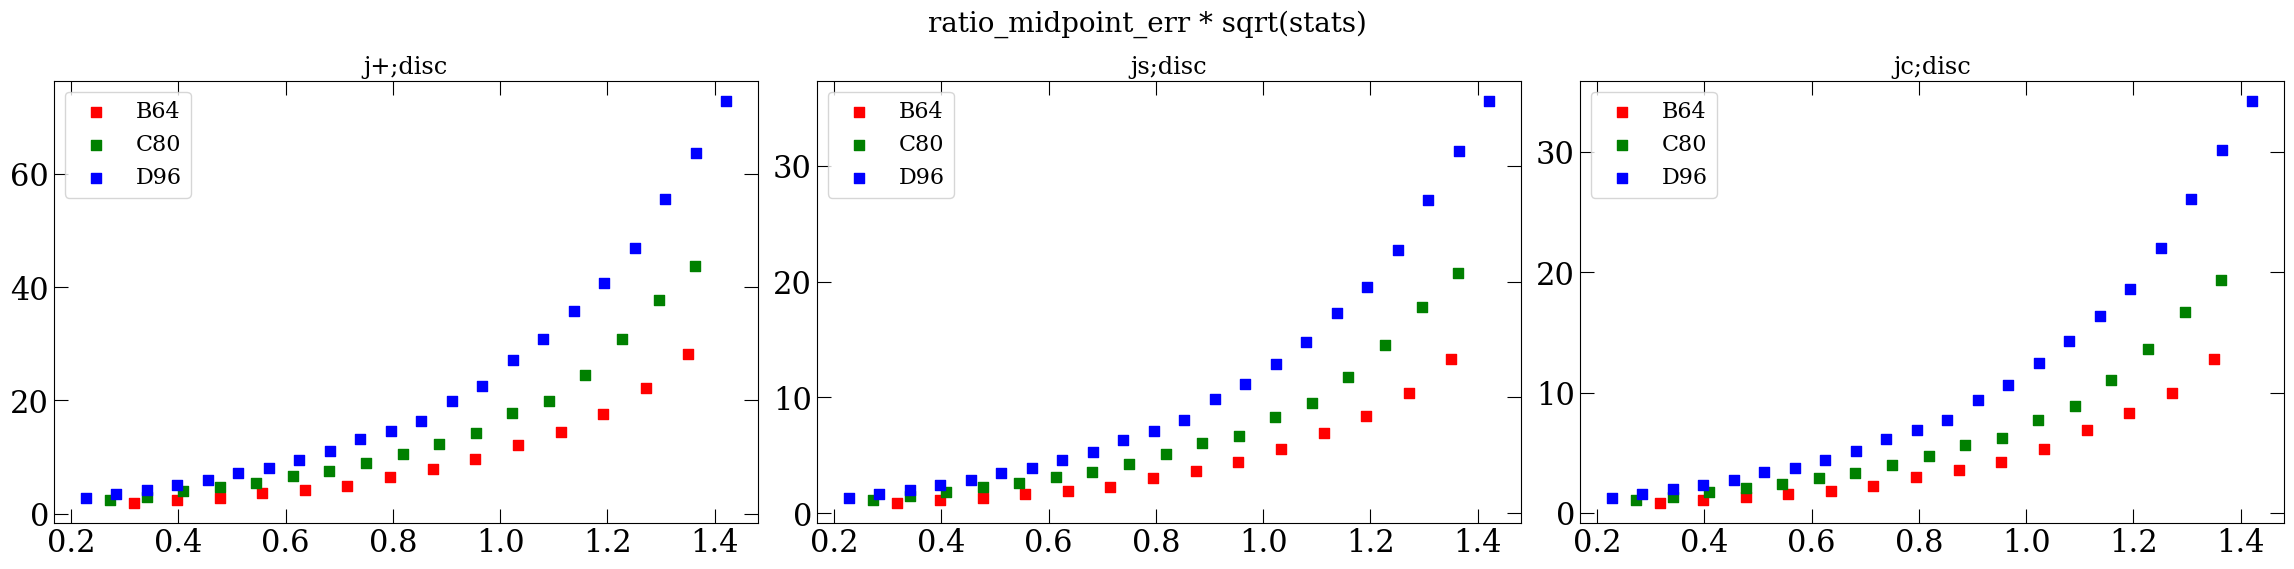

In [66]:
ens2Nsrcs={
    'b':200+85+64,
    'c':650,
    'd':256+112,
    'e':100+127+84,
}

gs=['j+;disc','js;disc','jc;disc']
flas=['']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle('ratio_midpoint_err * sqrt(stats)')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ifla,ig]
        for iens,ens in enumerate(enss[:3]):
            xunit=yu.ens2a[ens]
            for itf,tf in enumerate(range(4,int(1.5/xunit))):
                t=key2tf2ratio[(ens,g)][tf][:,tf//2]
                
                Ncfg=len(t); Nsrc=ens2Nsrcs[ens]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale
                ax.scatter(tf*xunit,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()

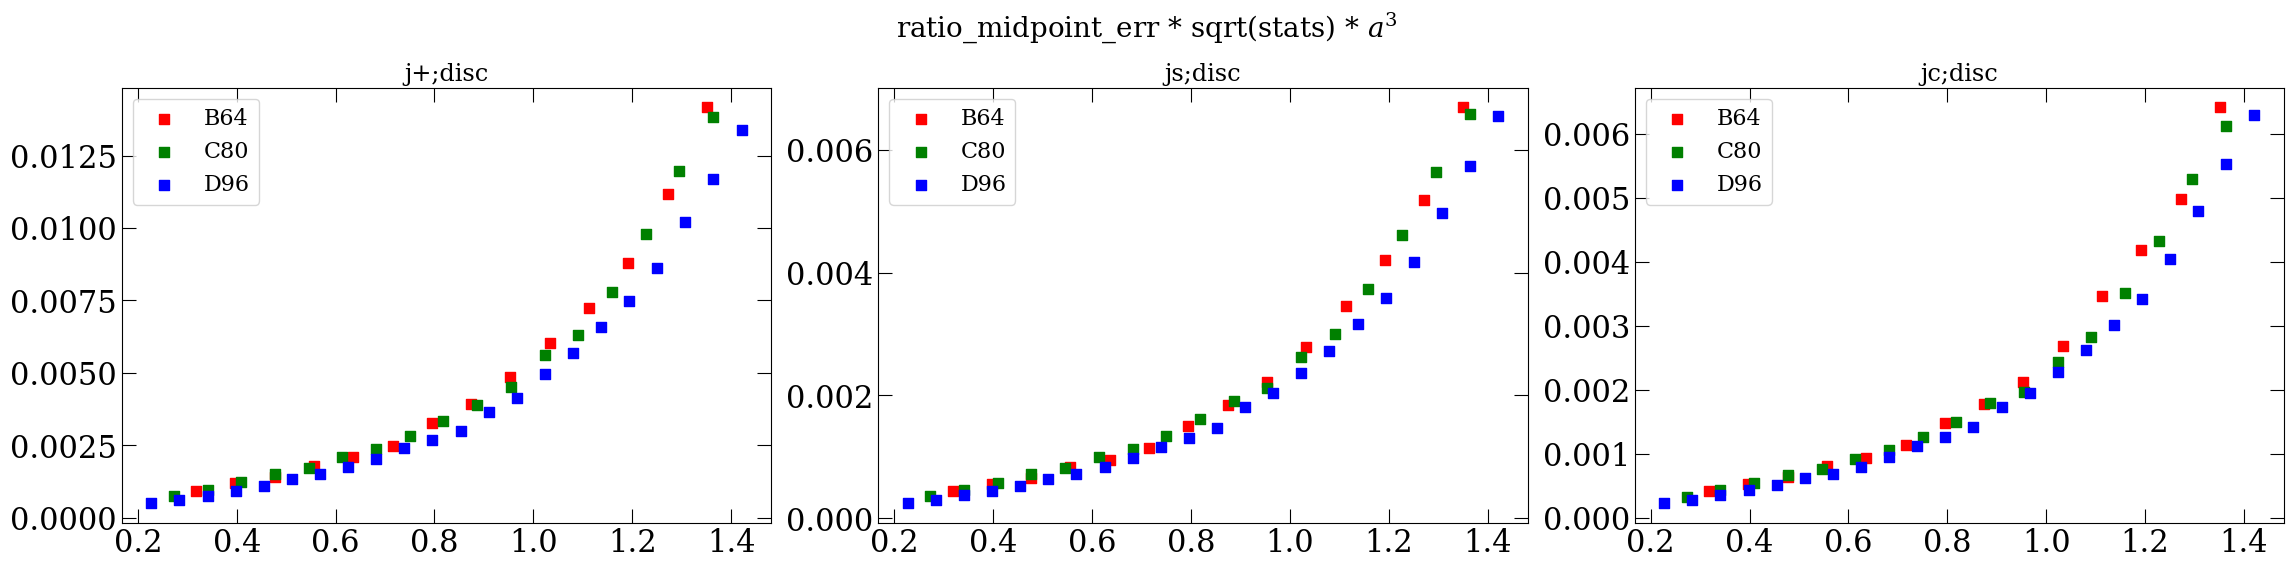

In [63]:
ens2Nsrcs={
    'b':200+85+64,
    'c':650,
    'd':256+112,
    'e':100+127+84,
}

gs=['j+;disc','js;disc','jc;disc']
flas=['']

fig, axs = yu.getFigAxs(len(flas),len(gs))
fig.suptitle(r'ratio_midpoint_err * sqrt(stats) * $a^3$')
yu.addRowHeader(axs,flas)
yu.addColHeader(axs,gs)
for ifla,fla in enumerate(flas):
    for ig,g in enumerate(gs):
        ax=axs[ifla,ig]
        for iens,ens in enumerate(enss[:3]):
            xunit=yu.ens2a[ens]
            for itf,tf in enumerate(range(4,int(1.5/xunit))):
                t=key2tf2ratio[(ens,g)][tf][:,tf//2]
                
                Ncfg=len(t); Nsrc=ens2Nsrcs[ens]
                rescale=np.sqrt(Ncfg*Nsrc)
                mean,err=yu.jackme(t)
                plt_y=err*rescale * (yu.ens2a[ens]**3)
                ax.scatter(tf*xunit,plt_y, color=yu.colors8[iens], marker='s', label=yu.ens2label[ens] if itf==0 else None)
        ax.legend()
yu.finalizePlot()